# Part 4: Evaluation & Measurement — Fairness Metrics

**vfairness.evaluation** — Metrics, statistics, visualization

This notebook demonstrates all features of the **vfairness Evaluation Module** for measuring, explaining, and visualising fairness in machine learning models.

The vfairness library is organized into eight parts following the ML fairness pipeline:
- **Part 1 — Data & Preprocessing** (`vfairness.preprocessing`) — Feature transforms, bias auditing
- **Part 2 — Training-Time Interventions** (`vfairness.in_processing`) — Losses, constraints, regularizers
- **Part 3 — Prediction-Time Interventions** (`vfairness.post_processing`) — Calibration, threshold tuning
- **Part 4 — Evaluation & Measurement** (`vfairness.evaluation`) — Metrics, statistics, visualization
- **Part 5 — Operations & Monitoring** (`vfairness.operations`) — MLOps, real-time monitoring, drift detection
- **Part 6 — Reporting & Dashboards** (`vfairness.operations.reporting`) — Interactive dashboards, automated reports
- **Part 7 — Experimentation** (`vfairness.operations.experimentation`) — A/B testing, Pareto & causal
- **Part 8 — Workflow Integration** (`vfairness.operations.cicd`) — CI/CD gates, pre-commit hooks, pytest plugin, report cards

> This notebook covers **Part 4** — the complete evaluation and measurement toolkit.

---

### Section I — Setup & Core Metrics
1. **Generate Sample Data** — Synthetic loan-approval dataset with built-in bias
2. **Basic Fairness Metrics** — Demographic parity, equalized odds, equal opportunity, predictive parity
3. **Unified FairnessAnalyzer Class** — Single interface for all fairness computations

### Section II — Statistical Rigour
4. **Statistical Validation** — Bootstrap confidence intervals for fairness metrics
5. **Bayesian Methods for Small Samples** — Conjugate-prior credible intervals & automatic method selection
6. **Effect Sizes** — Cohen's d, risk ratio, odds ratio with detailed interpretation

### Section III — Reporting & Explainability
7. **Comprehensive Fairness Report** — Full audit report with CI and multiple-testing correction
8. **FairExplAIner Mode** — AI-powered plain-language explanations of every metric

### Section IV — Advanced Analysis
9. **Intersectional Group Analysis** — Identify privileged/disadvantaged subgroups
10. **Auto-Discovery Features** — Detect protected attributes, proxy features, and violations
11. **Statistical Significance Testing** — Permutation tests, chi-square, Cramér's V
12. **Multiple Testing Corrections** — Bonferroni & Benjamini-Hochberg FDR

### Section V — Beyond Classification
13. **Regression Fairness** — MAE/RMSE parity, mean prediction difference
14. **Ranking Fairness (Exposure Parity)** — Attention-weighted rank fairness

### Section VI — Integrations & Tooling
15. **pytest Assertions for CI/CD** — `assert_fairness` for automated pipelines
16. **MLflow Integration** *(optional)* — Log fairness metrics to experiment tracking
17. **Visualization** *(optional)* — Matplotlib & Plotly dashboards in 4 professional styles

In [1]:
# Setup: Install vfairness if needed
import sys
sys.path.insert(0, './src')

import numpy as np
import pandas as pd
np.random.seed(42)

## 1. Generate Sample Data

We'll create synthetic data representing a loan approval model with potential bias.

In [2]:
# Generate synthetic loan approval data
n_samples = 1000

# Protected attributes
gender = np.random.choice(['Male', 'Female'], n_samples, p=[0.55, 0.45])
age_group = np.random.choice(['Young', 'Middle', 'Senior'], n_samples, p=[0.3, 0.5, 0.2])

# Ground truth (actual loan worthiness)
y_true = np.random.binomial(1, 0.6, n_samples)

# Predictions with some bias
# Males have higher approval rate, regardless of true worthiness
bias_factor = np.where(gender == 'Male', 0.15, -0.05)
prob = np.clip(0.5 + bias_factor + 0.2 * y_true + np.random.normal(0, 0.1, n_samples), 0, 1)
y_pred = (prob > 0.5).astype(int)

# Probability predictions
y_prob = prob

print(f"Dataset size: {n_samples}")
print(f"Gender distribution: {pd.Series(gender).value_counts().to_dict()}")
print(f"Overall approval rate: {y_pred.mean():.2%}")
print(f"Male approval rate: {y_pred[gender == 'Male'].mean():.2%}")
print(f"Female approval rate: {y_pred[gender == 'Female'].mean():.2%}")

Dataset size: 1000
Gender distribution: {'Male': 559, 'Female': 441}
Overall approval rate: 84.70%
Male approval rate: 97.85%
Female approval rate: 68.03%


## 2. Basic Fairness Metrics

In [3]:
from vfairness import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equal_opportunity_difference,
    predictive_parity_difference
)

# Compute basic metrics
print("=" * 50)
print("CLASSIFICATION FAIRNESS METRICS")
print("=" * 50)

dp_diff = demographic_parity_difference(y_true, y_pred, gender)
print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"  Interpretation: {'PASS' if abs(dp_diff) <= 0.1 else 'FAIL'} (threshold: 0.1)")

dp_ratio = demographic_parity_ratio(y_true, y_pred, gender)
print(f"\nDemographic Parity Ratio: {dp_ratio:.4f}")
print(f"  80% Rule: {'PASS' if dp_ratio >= 0.8 else 'FAIL'}")

eo_diff = equalized_odds_difference(y_true, y_pred, gender)
print(f"\nEqualized Odds Difference: {eo_diff:.4f}")

eop_diff = equal_opportunity_difference(y_true, y_pred, gender)
print(f"Equal Opportunity Difference: {eop_diff:.4f}")

pp_diff = predictive_parity_difference(y_true, y_pred, gender)
print(f"Predictive Parity Difference: {pp_diff:.4f}")

CLASSIFICATION FAIRNESS METRICS
Demographic Parity Difference: 0.2983
  Interpretation: FAIL (threshold: 0.1)

Demographic Parity Ratio: 0.6952
  80% Rule: FAIL

Equalized Odds Difference: 0.6262
Equal Opportunity Difference: 0.0692
Predictive Parity Difference: 0.1961


## 3. Unified FairnessAnalyzer Class

The `FairnessAnalyzer` provides a single interface for all fairness computations.

In [4]:
from vfairness import FairnessAnalyzer

# Create analyzer
analyzer = FairnessAnalyzer(y_true, y_pred, gender)

print(f"Analyzer: {analyzer}")
print(f"Task type: {analyzer.task_type}")
print(f"Groups: {analyzer.groups}")
print(f"Group sizes: {analyzer.group_sizes}")

Analyzer: FairnessAnalyzer(task_type='classification', n_samples=1000, groups=['Female', 'Male'], backend='native')
Task type: classification
Groups: ['Female', 'Male']
Group sizes: {'Female': 441, 'Male': 559}


In [5]:
# Compute all metrics at once
all_metrics = analyzer.compute_all_metrics()

print("\nAll Metrics (Point Estimates):")
for name, value in all_metrics.items():
    if isinstance(value, float):
        print(f"  {name}: {value:.4f}")


All Metrics (Point Estimates):
  demographic_parity_difference: 0.2983
  equalized_odds_difference: 0.6262
  equal_opportunity_difference: 0.0692
  demographic_parity_ratio: 0.6952
  predictive_parity_difference: 0.1961


### 📊 SVG Visual Dashboard

Generate an SVG fairness dashboard from the analyzer using the `vfairness.rendering` module:

SVG dashboard size: 6,335 bytes


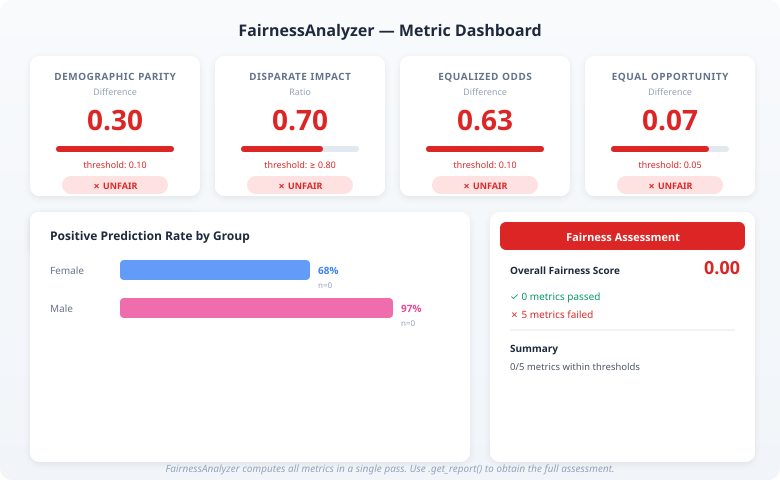

In [41]:
# Generate SVG fairness dashboard
from IPython.display import SVG, display
from vfairness.rendering import fairness_report_to_svg

# get_report() produces the dict needed by the SVG renderer
report = analyzer.get_report()
svg_output = fairness_report_to_svg(report)
print(f"SVG dashboard size: {len(svg_output):,} bytes")
display(SVG(data=svg_output))

## 4. Statistical Validation with Confidence Intervals

In [6]:
from vfairness import demographic_parity_difference_with_ci

# Compute with confidence interval
result = demographic_parity_difference_with_ci(
    y_true, y_pred, gender,
    n_bootstrap=2000,  # Use more for production (5000+)
    confidence_level=0.95,
    random_state=42
)

print("Demographic Parity Difference with 95% CI:")
print(f"  Point estimate: {result.point_estimate:.4f}")
print(f"  95% CI: [{result.lower_bound:.4f}, {result.upper_bound:.4f}]")
print(f"  Standard error: {result.standard_error:.4f}")
print(f"  Interval type: {result.interval_type.value}")
print(f"  Statistically significant: {result.is_significant}")

Demographic Parity Difference with 95% CI:
  Point estimate: 0.2983
  95% CI: [0.2563, 0.3440]
  Standard error: 0.0229
  Interval type: confidence
  Statistically significant: True


In [7]:
result = analyzer.demographic_parity_difference(include_ci=True, n_bootstrap=2000, random_state=42)
# Returns: MetricResult with .value, .confidence_interval, .effect_size, .is_fair, etc.
print(f"\nAnalyzer Demographic Parity Difference - Complete Results:")
print(f"  Metric: {result.metric_name}")
print(f"  Point estimate: {result.value:.4f}")
print(f"  95% CI: {result.confidence_interval}")
print(f"  Effect size: {result.effect_size:.4f}")
print(f"  Effect interpretation: {result.effect_interpretation}")
print(f"  Is fair: {result.is_fair}")
print(f"  Statistical significance: {'Yes' if result.confidence_interval[0] * result.confidence_interval[1] > 0 else 'No'}")

# Show additional attributes if available
if hasattr(result, 'p_value'):
    print(f"  P-value: {result.p_value:.4f}")
if hasattr(result, 'standard_error'):
    print(f"  Standard error: {result.standard_error:.4f}")
if hasattr(result, 'threshold'):
    print(f"  Fairness threshold: {result.threshold}")

print(f"\nInterpretation Guide:")
print(f"  • Effect size {result.effect_size:.4f} is considered '{result.effect_interpretation}'")
print(f"  • Confidence interval {'excludes' if result.confidence_interval[0] * result.confidence_interval[1] > 0 else 'includes'} zero")
print(f"  • Model is {'fair' if result.is_fair else 'unfair'} according to this metric")


Analyzer Demographic Parity Difference - Complete Results:
  Metric: demographic_parity_difference
  Point estimate: 0.2983
  95% CI: (np.float64(0.25625702278526197), np.float64(0.343968517639614))
  Effect size: -0.9081
  Effect interpretation: large effect
  Is fair: False
  Statistical significance: Yes
  Fairness threshold: 0.1

Interpretation Guide:
  • Effect size -0.9081 is considered 'large effect'
  • Confidence interval excludes zero
  • Model is unfair according to this metric


## 5. Bayesian Methods for Small Samples

When group sizes are small (< 30 samples), frequentist bootstrap confidence intervals become unreliable. vfairness provides **Bayesian credible intervals** using conjugate Beta priors, and an **automatic method selector** that chooses the appropriate approach based on sample size.

In [8]:
from vfairness import bayesian_proportion_ci, bayesian_difference_ci, select_method

# Small sample example
small_successes = 7
small_trials = 20

result = bayesian_proportion_ci(small_successes, small_trials, confidence_level=0.95)

print("Bayesian Credible Interval for Small Sample:")
print(f"  Observed: {small_successes}/{small_trials} = {small_successes/small_trials:.1%}")
print(f"  Posterior mean: {result.point_estimate:.3f}")
print(f"  95% Credible Interval: [{result.lower_bound:.3f}, {result.upper_bound:.3f}]")
print(f"  Interval type: {result.interval_type.value}")

Bayesian Credible Interval for Small Sample:
  Observed: 7/20 = 35.0%
  Posterior mean: 0.364
  95% Credible Interval: [0.202, 0.511]
  Interval type: credible


In [9]:
# Automatic method selection
group_sizes = {'Large_Group': 500, 'Medium_Group': 50, 'Small_Group': 20}
overall_method, per_group = select_method(group_sizes)

print("Automatic Method Selection:")
print(f"  Overall method: {overall_method}")
print(f"  Per-group methods: {per_group}")

Automatic Method Selection:
  Overall method: mixed
  Per-group methods: {'Large_Group': 'bootstrap', 'Medium_Group': 'bootstrap', 'Small_Group': 'bayesian'}


## 6. Effect Sizes

In [10]:
from vfairness import compute_effect_sizes, cohens_d, risk_ratio, odds_ratio

# Compute pairwise effect sizes
effects = compute_effect_sizes(y_true, y_pred, gender)

print("Effect Sizes (Pairwise Comparisons):")
for pair, e in effects.items():
    print(f"\n{pair}:")
    print(f"  Cohen's d: {e['cohens_d_positive_rate']:.4f} ({e['interpretation']})")
    rr, rr_l, rr_u = e['risk_ratio']
    print(f"  Risk Ratio: {rr:.3f} [{rr_l:.3f}, {rr_u:.3f}]")
    or_val, or_l, or_u = e['odds_ratio']
    print(f"  Odds Ratio: {or_val:.3f} [{or_l:.3f}, {or_u:.3f}]")
    print(f"  Group sizes: {e['group1_size']} vs {e['group2_size']}")

# Quick interpretation
print(f"\n📊 DETAILED INTERPRETATION:")
for pair, e in effects.items():
    rr, rr_l, rr_u = e['risk_ratio']
    or_val, or_l, or_u = e['odds_ratio']
    cohens_d_raw = e['cohens_d_positive_rate']
    cohens_d = abs(cohens_d_raw)
    
    print(f"\n🔍 {pair} Analysis:")
    print(f"   Bias Magnitude: {e['interpretation']} (Cohen's d = {cohens_d:.3f})")
    
    # Risk Ratio Analysis
    print(f"\n   📈 Risk Ratio: {rr:.3f} [{rr_l:.3f} - {rr_u:.3f}]")
    print(f"      → Disadvantaged group approved at {rr:.1%} the rate of advantaged group")
    print(f"      → {'❌ Fails 80% rule' if rr < 0.8 else '✅ Passes 80% rule'} (EEOC threshold: 80%)")
    if rr < 0.5:
        print(f"      → 🚨 EXTREME: Less than half the approval rate!")
    elif rr < 0.7:
        print(f"      → ⚠️  SEVERE: Major disparate impact")
    elif rr < 0.8:
        print(f"      → ⚠️  MODERATE: Below legal threshold")
    
    # Odds Ratio Analysis  
    print(f"\n   🎲 Odds Ratio: {or_val:.3f} [{or_l:.3f} - {or_u:.3f}]")
    if or_val < 0.1:
        print(f"      → Disadvantaged group has <10% the odds of approval")
        print(f"      → 🚨 CRITICAL: Virtually impossible to get approved")
    elif or_val < 0.5:
        print(f"      → Disadvantaged group has {or_val:.1%} the odds of approval")
        print(f"      → ⚠️  SEVERE: Dramatically reduced chances")
    else:
        print(f"      → Disadvantaged group has {or_val:.1%} the odds of approval")
    
    # Cohen's d Analysis
    print(f"\n   📏 Effect Size: {cohens_d:.3f} ({'negative' if cohens_d_raw < 0 else 'positive'} direction)")
    if cohens_d < 0.2:
        print(f"      → Small practical difference")
    elif cohens_d < 0.5:
        print(f"      → Medium practical difference")
    elif cohens_d < 0.8:
        print(f"      → Large practical difference")
    else:
        print(f"      → Very large practical difference ({cohens_d/0.8:.1f}x the 'large' threshold)")
    
    # Sample Size Assessment
    total_samples = e['group1_size'] + e['group2_size']
    smaller_group = min(e['group1_size'], e['group2_size'])
    print(f"\n   👥 Sample Reliability: {total_samples} total ({e['group1_size']} vs {e['group2_size']})")
    if smaller_group < 30:
        print(f"      → ⚠️  Small sample warning: Results may be unstable")
    elif smaller_group < 100:
        print(f"      → Adequate sample size for basic analysis")
    else:
        print(f"      → ✅ Excellent sample size for reliable results")
    
    # Overall Assessment
    print(f"\n   ⚖️  OVERALL ASSESSMENT:")
    if cohens_d > 0.8 and rr < 0.8:
        print(f"      🚨 CRITICAL BIAS: Both statistical and practical significance")
        print(f"      📋 Action: Immediate model revision required before deployment")
        print(f"      ⚖️  Legal: High risk of discrimination claims")
    elif cohens_d > 0.5 and rr < 0.8:
        print(f"      ⚠️  SIGNIFICANT BIAS: Violates fairness standards")
        print(f"      📋 Action: Bias mitigation strongly recommended")  
    elif rr < 0.8:
        print(f"      ⚠️  REGULATORY CONCERN: Below 80% rule threshold")
        print(f"      📋 Action: Review and document business justification")
    else:
        print(f"      ✅ ACCEPTABLE: Within reasonable fairness bounds")
        print(f"      📋 Action: Continue monitoring in production")
        
print(f"\n" + "="*80)
print(f"💡 KEY TAKEAWAYS:")
print(f"   • Cohen's d >0.8 = Large bias requiring immediate attention")
print(f"   • Risk Ratio <0.8 = Fails EEOC 80% rule for disparate impact") 
print(f"   • Odds Ratio <0.1 = Extreme discrimination (10x less likely)")
print(f"   • Confidence intervals that exclude 1.0 = Statistically significant bias")
print(f"="*80)

Effect Sizes (Pairwise Comparisons):

Female_vs_Male:
  Cohen's d: -0.9081 (large effect)
  Risk Ratio: 0.695 [0.651, 0.742]
  Odds Ratio: 0.047 [0.025, 0.086]
  Group sizes: 441 vs 559

📊 DETAILED INTERPRETATION:

🔍 Female_vs_Male Analysis:
   Bias Magnitude: large effect (Cohen's d = 0.908)

   📈 Risk Ratio: 0.695 [0.651 - 0.742]
      → Disadvantaged group approved at 69.5% the rate of advantaged group
      → ❌ Fails 80% rule (EEOC threshold: 80%)
      → ⚠️  SEVERE: Major disparate impact

   🎲 Odds Ratio: 0.047 [0.025 - 0.086]
      → Disadvantaged group has <10% the odds of approval
      → 🚨 CRITICAL: Virtually impossible to get approved

   📏 Effect Size: 0.908 (negative direction)
      → Very large practical difference (1.1x the 'large' threshold)

   👥 Sample Reliability: 1000 total (441 vs 559)
      → ✅ Excellent sample size for reliable results

   ⚖️  OVERALL ASSESSMENT:
      🚨 CRITICAL BIAS: Both statistical and practical significance
      📋 Action: Immediate model r

## 7. Comprehensive Fairness Report

In [11]:
from vfairness import classification_fairness_report, print_report

# Generate full report with CI
report = classification_fairness_report(
    y_true, y_pred, gender,
    include_ci=True,
    n_bootstrap=2000,
    confidence_level=0.95,
    multiple_testing_correction='fdr',  # Benjamini-Hochberg
    random_state=42
)

# Print formatted report
print_report(report)

VFAIRNESS REPORT - CLASSIFICATION

Data Summary:
  Samples: 1000 (excluded 0 with missing values)
  Groups: 2 (2 valid, 0 below min size)
  Intersectional: False

Fairness Metrics:
  demographic_parity_difference: 0.2983
  demographic_parity_ratio: 0.6952
  equalized_odds_difference: 0.6262
  equal_opportunity_difference: 0.0692
  predictive_parity_difference: 0.1961

Assessment:
  Fairness Score: 0.0%
  0/5 metrics within thresholds

  Failed Metrics:
    - demographic_parity_difference: 0.2983 (threshold: 0.1000)
    - demographic_parity_ratio: 0.6952 (threshold: 0.8000)
    - equalized_odds_difference: 0.6262 (threshold: 0.1000)
    - equal_opportunity_difference: 0.0692 (threshold: 0.0500)
    - predictive_parity_difference: 0.1961 (threshold: 0.0500)


In [12]:
# Access specific parts of the report
print("\nDetailed Assessment:")
print(f"  Fairness Score: {report['assessment']['fairness_score']:.1%}")
print(f"  Summary: {report['assessment']['summary']}")

if report['assessment']['failed_metrics']:
    print("\n  Failed Metrics:")
    for m in report['assessment']['failed_metrics']:
        print(f"    - {m['metric']}: {m['value']:.4f} (threshold: {m['threshold']})")


Detailed Assessment:
  Fairness Score: 0.0%
  Summary: 0/5 metrics within thresholds

  Failed Metrics:
    - demographic_parity_difference: 0.2983 (threshold: 0.1)
    - demographic_parity_ratio: 0.6952 (threshold: 0.8)
    - equalized_odds_difference: 0.6262 (threshold: 0.1)
    - equal_opportunity_difference: 0.0692 (threshold: 0.05)
    - predictive_parity_difference: 0.1961 (threshold: 0.05)


## 8. FairExplAIner Mode

FairExplAIner provides intelligent, human-readable explanations for all fairness metrics. It helps stakeholders understand what metrics mean, how to interpret results, and what actions to take.

In [13]:
from vfairness import FairExplAIner, explain_fairness_report, print_explanations

# Method 1: Use FairExplAIner mode in FairnessAnalyzer
analyzer_with_explainer = FairnessAnalyzer(y_true, y_pred, gender, fair_explainer=True)
report_with_explanations = analyzer_with_explainer.get_report(include_ci=True, n_bootstrap=1000)

print("=" * 60)
print("FAIRNESS REPORT WITH FAIREXPLAINER EXPLANATIONS")
print("=" * 60)

# print_report automatically shows explanations when available
print_report(report_with_explanations)

FAIRNESS REPORT WITH FAIREXPLAINER EXPLANATIONS
VFAIRNESS REPORT - CLASSIFICATION
FairExplAIner Mode: ENABLED

Data Summary:
  Samples: 1000 (excluded 0 with missing values)
  Groups: 2 (2 valid, 0 below min size)
  Intersectional: False

Fairness Metrics:
  demographic_parity_difference: 0.2983
  demographic_parity_ratio: 0.6952
  equalized_odds_difference: 0.6262
  equal_opportunity_difference: 0.0692
  predictive_parity_difference: 0.1961

Assessment:
  Fairness Score: 0.0%
  0/5 metrics within thresholds

  Failed Metrics:
    - demographic_parity_difference: 0.2983 (threshold: 0.1000)
    - demographic_parity_ratio: 0.6952 (threshold: 0.8000)
    - equalized_odds_difference: 0.6262 (threshold: 0.1000)
    - equal_opportunity_difference: 0.0692 (threshold: 0.0500)
    - predictive_parity_difference: 0.1961 (threshold: 0.0500)


FAIREXPLAINER - Detailed Metric Explanations

SUMMARY:
  Overall Fairness Score: 0.0% (0 passed, 5 failed) | CRITICAL: 4 metric(s) show critical disparities

In [14]:
# Method 2: Standalone FairExplAIner on existing report
explanations = explain_fairness_report(report, include_statistical=True)

print("\n" + "=" * 60)
print("STANDALONE FAIREXPLAINER USAGE")
print("=" * 60)

# Access individual explanations
for metric_name, explanation in explanations['metrics'].items():
    print(f"\n📊 {metric_name}")
    print(f"   Definition: {explanation['definition'][:80]}...")
    print(f"   Value: {explanation['value']:.4f}")
    print(f"   Evaluation: {explanation['evaluation']}")
    print(f"   Action: {explanation['recommendation'][:60]}...")

# Print summary
print(f"\n📋 SUMMARY: {explanations['summary']}")


STANDALONE FAIREXPLAINER USAGE

📊 demographic_parity_difference
   Definition: Demographic Parity Difference measures the maximum absolute difference in positi...
   Value: 0.2983
   Evaluation: Critical. The difference of 0.2983 indicates severe disparity that requires immediate investigation and remediation.
   Action: URGENT: Review deployment decisions for this model. Consider...

📊 demographic_parity_ratio
   Definition: Demographic Parity Ratio (also called Disparate Impact Ratio) measures the ratio...
   Value: 0.6952
   Evaluation: Critical. The ratio of 0.6952 indicates severe disparity that may constitute discrimination.
   Action: URGENT: Review deployment decisions for this model. Consider...

📊 equalized_odds_difference
   Definition: Equalized Odds Difference measures the maximum of (a) the TPR difference and (b)...
   Value: 0.6262
   Evaluation: Critical. The difference of 0.6262 indicates severe disparity that requires immediate investigation and remediation.
   Actio

## 9. Intersectional Group Analysis

vfairness provides detailed intersectional analysis to identify which specific groups are most affected by disparities. This answers the critical question: "We know there's a disparity — but WHO is most affected?"

In [15]:
from vfairness.evaluation.vfairness_metrics.intersectional import identify_privileged_groups, intersectional_disparity_analysis, get_group_rankings

# Create combined intersectional attribute
gender_age = np.array([f"{g}_{a}" for g, a in zip(gender, age_group)])

print("=" * 60)
print("INTERSECTIONAL GROUP ANALYSIS")
print("=" * 60)

# Identify most/least advantaged groups
result = identify_privileged_groups(y_true, y_pred, gender_age, min_group_size=30)

print("\n📊 Group Advantage Analysis:")
print(f"   Most advantaged group: {result['privileged_group'].group}")
print(f"   - Positive rate: {result['privileged_group'].positive_rate:.1%}")
print(f"   - Size: {result['privileged_group'].size}")

print(f"\n   Most disadvantaged group: {result['disadvantaged_group'].group}")
print(f"   - Positive rate: {result['disadvantaged_group'].positive_rate:.1%}")
print(f"   - Size: {result['disadvantaged_group'].size}")

print(f"\n   Maximum disparity: {result['max_disparity']:.1%}")
print(f"   Severity: {result['disparity_severity']}")

INTERSECTIONAL GROUP ANALYSIS

📊 Group Advantage Analysis:
   Most advantaged group: Male_Young
   - Positive rate: 100.0%
   - Size: 170

   Most disadvantaged group: Female_Middle
   - Positive rate: 65.9%
   - Size: 232

   Maximum disparity: 34.1%
   Severity: critical


In [16]:
# Full intersectional disparity analysis
analysis = intersectional_disparity_analysis(
    y_true, y_pred,
    gender_age,  # Combined intersectional attribute
    single_attributes={'gender': gender, 'age_group': age_group}
)

print("\n" + "=" * 60)
print("INTERSECTIONAL VS SINGLE-ATTRIBUTE COMPARISON")
print("=" * 60)

# Check for hidden disparities
print(f"\nSingle-attribute max disparities:")
for attr, disp in analysis['comparison']['single_attribute_disparities'].items():
    print(f"   {attr}: {disp:.1%}")
print(f"Intersectional max disparity: {analysis['comparison']['intersectional_disparity']:.1%}")

if analysis['comparison']['intersectional_reveals_more']:
    print(f"\n⚠️  Hidden disparity detected: {analysis['comparison']['hidden_disparity']:.1%}")
    print("   Intersectional analysis reveals larger disparities than single attributes!")

# Human-readable insights
print(f"\n📋 KEY INSIGHTS:")
for insight in analysis['insights']:
    print(f"   • {insight}")


INTERSECTIONAL VS SINGLE-ATTRIBUTE COMPARISON

Single-attribute max disparities:
   gender: 29.8%
   age_group: 5.1%
Intersectional max disparity: 34.1%

⚠️  Hidden disparity detected: 4.2%
   Intersectional analysis reveals larger disparities than single attributes!

📋 KEY INSIGHTS:
   • Maximum disparity of 34.1% found between 'Male_Young' (rate: 100.0%) and 'Female_Middle' (rate: 65.9%).
   • 'Female_Middle' receives positive predictions at 65.9% the rate of 'Male_Young' (1.5x disadvantage).
   • Severity: CRITICAL - This disparity is severe and requires immediate action.
   • Intersectional analysis reveals 4.2% additional disparity not visible when analyzing gender alone (single-attribute disparity: 29.8%).
   • Intersectional analysis reveals 29.0% additional disparity not visible when analyzing age_group alone (single-attribute disparity: 5.1%).


## 10. Auto-Discovery Features

vfairness can automatically detect protected attributes, identify proxy features, and scan for fairness violations across your dataset.

In [17]:
from vfairness.evaluation.vfairness_metrics.discovery import (
    detect_protected_attributes,
    identify_proxy_features,
    scan_fairness_violations,
    rank_fairness_issues
)

# Create a DataFrame with potential protected attributes
df = pd.DataFrame({
    'gender': gender,
    'age_group': age_group,
    'income': np.random.normal(50000, 20000, n_samples),
    'zip_code': np.random.choice(['10001', '10002', '10003', '10004'], n_samples),
    'credit_score': np.random.normal(700, 50, n_samples),
    'years_employed': np.random.exponential(5, n_samples)
})

print("=" * 60)
print("AUTO-DISCOVERY FEATURES")
print("=" * 60)

# Auto-detect protected attributes
print("\n🔍 Auto-Detecting Protected Attributes...")
candidates = detect_protected_attributes(
    df,
    min_confidence=0.3,
    exclude_columns=['income', 'credit_score', 'years_employed']
)

print(f"\nDetected {len(candidates)} potential protected attributes:")
for candidate in candidates:
    print(f"   • {candidate.column}: {candidate.confidence:.0%} confidence ({candidate.category})")
    print(f"     Reason: {candidate.reason}")

AUTO-DISCOVERY FEATURES

🔍 Auto-Detecting Protected Attributes...

Detected 3 potential protected attributes:
   • gender: 100% confidence (demographic)
     Reason: Exact column name match: 'gender'; Binary protected pattern: ['Male', 'Female']; Values match gender pattern: ['female', 'male']; Low-cardinality categorical (2 values); Categorical data type
   • age_group: 70% confidence (demographic)
     Reason: Column name contains 'age'; Low-cardinality categorical (3 values); Categorical data type
   • zip_code: 70% confidence (geographic)
     Reason: Column name contains 'zip'; High-risk proxy for 'race'; Low-cardinality categorical (4 values); Categorical data type [PROXY WARNING: may correlate with race]


In [18]:
# Scan for fairness violations
print("\n🔍 Scanning for Fairness Violations...")
violations = scan_fairness_violations(
    df, y_pred, y_true,
    protected_columns=['gender', 'age_group'],
    thresholds={'demographic_parity_difference': 0.1}
)

print(f"\nFound {len(violations)} violations:")
for v in violations[:3]:  # Show top 3
    print(f"   • {v.metric} on '{v.attribute}': {v.disparity:.3f}")
    print(f"     Severity: {v.severity}")
    print(f"     Groups: {v.privileged_group} vs {v.disadvantaged_group}")


🔍 Scanning for Fairness Violations...

Found 3 violations:
   • equalized_odds_difference on 'gender': 0.626
     Severity: critical
     Groups: Female vs Male
   • demographic_parity_difference on 'gender': 0.298
     Severity: critical
     Groups: Female vs Male
   • predictive_parity_difference on 'gender': 0.196
     Severity: high
     Groups: Female vs Male


## 11. Statistical Significance Testing

vfairness provides formal hypothesis testing for fairness audits, including permutation tests (gold standard for formal audits), robust statistics for handling outliers, and sensitivity analysis for stress-testing conclusions.

In [19]:
from vfairness.evaluation.vfairness_metrics.robustness import (
    permutation_test_demographic_parity,
    permutation_test_equal_opportunity,
    contingency_test,
    compute_robust_metrics,
    subgroup_robustness_audit,
    comprehensive_fairness_test
)

print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTING")
print("=" * 60)

# Permutation test for demographic parity (gold standard)
print("\n🧪 Permutation Test for Demographic Parity:")
dp_result = permutation_test_demographic_parity(y_pred, gender, n_permutations=2000, random_state=42)
print(f"   Observed statistic: {dp_result.observed_statistic:.4f}")
print(f"   P-value: {dp_result.p_value:.4f}")
print(f"   Significant at α=0.05: {dp_result.significant_at_05}")
print(f"   Significant at α=0.01: {dp_result.significant_at_01}")

# Contingency table test (Chi-square / Fisher's exact)
print("\n🧪 Contingency Table Test:")
ct_result = contingency_test(y_pred, gender)
print(f"   Test used: {ct_result.test_used}")
print(f"   Statistic: {ct_result.statistic:.3f}")
print(f"   P-value: {ct_result.p_value:.4f}")
print(f"   Cramer's V (effect size): {ct_result.cramers_v:.3f}")

# ── Interpretation ──────────────────────────────────────────
print(f"\n{'─' * 60}")
print(f"📋 INTERPRETATION")
print(f"{'─' * 60}")

# Permutation test interpretation
print(f"\n🔬 Permutation Test (non-parametric, assumption-free):")
print(f"   What it does: Shuffles group labels {2000} times to build a null")
print(f"   distribution of 'no disparity', then checks where our observed")
print(f"   disparity ({dp_result.observed_statistic:.4f}) falls.")
print(f"")
if dp_result.p_value < 0.001:
    print(f"   📊 Result: p = {dp_result.p_value:.4f} → HIGHLY SIGNIFICANT (p < 0.001)")
    print(f"   The observed {dp_result.observed_statistic:.1%} gap in approval rates between")
    print(f"   groups would occur by random chance less than 0.1% of the time.")
    print(f"   This is extremely strong evidence that the disparity is REAL,")
    print(f"   not a statistical fluke.")
elif dp_result.p_value < 0.01:
    print(f"   📊 Result: p = {dp_result.p_value:.4f} → VERY SIGNIFICANT (p < 0.01)")
    print(f"   Strong evidence the disparity is systematic, not random.")
elif dp_result.p_value < 0.05:
    print(f"   📊 Result: p = {dp_result.p_value:.4f} → SIGNIFICANT (p < 0.05)")
    print(f"   The disparity is unlikely due to chance alone.")
else:
    print(f"   📊 Result: p = {dp_result.p_value:.4f} → NOT SIGNIFICANT (p ≥ 0.05)")
    print(f"   Cannot rule out that the observed difference is due to random variation.")

# Contingency test interpretation
print(f"\n🔬 Chi-Square Contingency Test (parametric):")
print(f"   What it does: Tests whether predictions and group membership")
print(f"   are statistically independent (unrelated).")
print(f"")
if ct_result.p_value < 0.001:
    print(f"   📊 Result: χ² = {ct_result.statistic:.1f}, p ≈ 0.0000 → HIGHLY SIGNIFICANT")
    print(f"   Predictions are NOT independent of group membership.")
    print(f"   The model's decisions are systematically associated with the")
    print(f"   protected attribute.")
elif ct_result.p_value < 0.05:
    print(f"   📊 Result: χ² = {ct_result.statistic:.1f}, p = {ct_result.p_value:.4f} → SIGNIFICANT")
else:
    print(f"   📊 Result: χ² = {ct_result.statistic:.1f}, p = {ct_result.p_value:.4f} → NOT SIGNIFICANT")

# Cramér's V interpretation
print(f"\n🔬 Effect Size (Cramér's V = {ct_result.cramers_v:.3f}):")
if ct_result.cramers_v < 0.1:
    v_label = "negligible"
    v_emoji = "✅"
elif ct_result.cramers_v < 0.3:
    v_label = "small-to-medium"
    v_emoji = "⚠️"
elif ct_result.cramers_v < 0.5:
    v_label = "medium-to-large"
    v_emoji = "🔶"
else:
    v_label = "large"
    v_emoji = "🚨"
print(f"   {v_emoji} Strength of association: {v_label}")
print(f"   Cramér's V ranges from 0 (no association) to 1 (perfect association).")
print(f"   A value of {ct_result.cramers_v:.3f} means group membership explains")
print(f"   a {'substantial' if ct_result.cramers_v >= 0.3 else 'moderate'} portion of the variation in model decisions.")

# Combined verdict
print(f"\n{'─' * 60}")
print(f"⚖️  COMBINED VERDICT")
print(f"{'─' * 60}")
both_sig = dp_result.significant_at_05 and ct_result.p_value < 0.05
if both_sig and ct_result.cramers_v >= 0.3:
    print(f"   🚨 CONFIRMED BIAS: Both tests agree the disparity is statistically")
    print(f"   significant AND the effect size is {v_label}.")
    print(f"   → The {dp_result.observed_statistic:.1%} approval rate gap is real and meaningful.")
    print(f"   → Action: Investigate root causes and apply bias mitigation.")
elif both_sig:
    print(f"   ⚠️  STATISTICALLY SIGNIFICANT DISPARITY with {v_label} effect size.")
    print(f"   → The disparity is real but may have limited practical impact.")
    print(f"   → Action: Monitor closely, consider mitigation if it worsens.")
else:
    print(f"   ✅ No strong evidence of systematic bias at this sample size.")
    print(f"   → Action: Continue monitoring as more data becomes available.")

print(f"\n   📖 Why two tests?")
print(f"   • Permutation test → Makes no distributional assumptions (gold standard)")
print(f"   • Chi-square test  → Faster, widely understood, provides Cramér's V")
print(f"   • Agreement between both tests strengthens confidence in the conclusion")

STATISTICAL SIGNIFICANCE TESTING

🧪 Permutation Test for Demographic Parity:
   Observed statistic: 0.2983
   P-value: 0.0005
   Significant at α=0.05: True
   Significant at α=0.01: True

🧪 Contingency Table Test:
   Test used: chi_square
   Statistic: 166.933
   P-value: 0.0000
   Cramer's V (effect size): 0.409

────────────────────────────────────────────────────────────
📋 INTERPRETATION
────────────────────────────────────────────────────────────

🔬 Permutation Test (non-parametric, assumption-free):
   What it does: Shuffles group labels 2000 times to build a null
   distribution of 'no disparity', then checks where our observed
   disparity (0.2983) falls.

   📊 Result: p = 0.0005 → HIGHLY SIGNIFICANT (p < 0.001)
   The observed 29.8% gap in approval rates between
   groups would occur by random chance less than 0.1% of the time.
   This is extremely strong evidence that the disparity is REAL,
   not a statistical fluke.

🔬 Chi-Square Contingency Test (parametric):
   What it do

## 12. Multiple Testing Corrections

In [20]:
from vfairness import bonferroni_correction, benjamini_hochberg_correction

# Simulate p-values from multiple fairness tests
p_values = np.array([0.01, 0.03, 0.04, 0.08, 0.12])
test_labels = ['Demographic Parity', 'Equal Opportunity', 'Predictive Parity', 'Equalized Odds', 'Calibration']

print("=" * 60)
print("MULTIPLE TESTING CORRECTIONS")
print("=" * 60)

print(f"\nOriginal p-values from {len(p_values)} simultaneous fairness tests:")
for label, p in zip(test_labels, p_values):
    sig = "✅ significant" if p < 0.05 else "  not significant"
    print(f"   {label:.<30} p = {p:.3f}  {sig}")

naive_rejected = sum(p_values < 0.05)
print(f"\n   → {naive_rejected}/{len(p_values)} tests significant at α=0.05 (uncorrected)")

# Bonferroni correction (conservative)
bonf = bonferroni_correction(p_values, alpha=0.05)
print(f"\n{'─' * 60}")
print(f"🔬 Bonferroni Correction (most conservative):")
print(f"   Method: Multiply each p-value by {len(p_values)} (number of tests)")
print(f"   Effective α per test: {0.05/len(p_values):.3f}")
print(f"\n   Adjusted p-values:")
for label, orig, adj, rej in zip(test_labels, p_values, bonf.adjusted_p_values, bonf.rejection_mask):
    status = "✅ REJECT H₀" if rej else "  retain H₀"
    print(f"   {label:.<30} {orig:.3f} → {adj:.3f}  {status}")
print(f"\n   Rejected: {bonf.n_rejected}/{len(p_values)} hypotheses")

# Benjamini-Hochberg correction (less conservative)
bh = benjamini_hochberg_correction(p_values, alpha=0.05)
print(f"\n{'─' * 60}")
print(f"🔬 Benjamini-Hochberg FDR Correction (less conservative):")
print(f"   Method: Controls False Discovery Rate (expected proportion of false positives)")
print(f"\n   Adjusted p-values:")
for label, orig, adj, rej in zip(test_labels, p_values, bh.adjusted_p_values, bh.rejection_mask):
    status = "✅ REJECT H₀" if rej else "  retain H₀"
    print(f"   {label:.<30} {orig:.3f} → {adj:.3f}  {status}")
print(f"\n   Rejected: {bh.n_rejected}/{len(p_values)} hypotheses")

# Interpretation
print(f"\n{'─' * 60}")
print(f"📋 INTERPRETATION")
print(f"{'─' * 60}")
print(f"\n   ⚠️  Why corrections matter:")
print(f"   When running {len(p_values)} tests at α=0.05, the probability of at least")
print(f"   one false positive rises to {1 - (1-0.05)**len(p_values):.1%} (family-wise error rate).")
print(f"   Multiple testing corrections control this inflation.")

print(f"\n   📊 Results comparison:")
print(f"   {'Method':<25} {'Significant Tests':<20} {'Conservativeness'}")
print(f"   {'─'*25} {'─'*20} {'─'*20}")
print(f"   {'Uncorrected':<25} {naive_rejected:<20} {'Most liberal (risky)'}")
print(f"   {'Benjamini-Hochberg':<25} {bh.n_rejected:<20} {'Moderate (recommended)'}")
print(f"   {'Bonferroni':<25} {bonf.n_rejected:<20} {'Most conservative (safe)'}")

if bonf.n_rejected == 0 and naive_rejected > 0:
    print(f"\n   💡 Key insight: The {naive_rejected} test(s) that appeared significant")
    print(f"   before correction are likely FALSE POSITIVES caused by testing")
    print(f"   multiple hypotheses simultaneously. After proper correction,")
    print(f"   no fairness violations reach statistical significance.")
    print(f"\n   🎯 Recommendation: The observed disparities may be due to random")
    print(f"   chance rather than systematic bias. However, monitor these metrics")
    print(f"   over time as sample sizes grow.")
elif bh.n_rejected > bonf.n_rejected:
    print(f"\n   💡 Key insight: BH finds {bh.n_rejected - bonf.n_rejected} more significant")
    print(f"   result(s) than Bonferroni. Use BH for exploratory analysis and")
    print(f"   Bonferroni for regulatory/legal compliance.")
elif bonf.n_rejected > 0:
    print(f"\n   💡 Key insight: {bonf.n_rejected} test(s) survive even the strictest")
    print(f"   correction — strong evidence of genuine fairness violations.")

print(f"\n   📖 When to use which:")
print(f"   • Bonferroni  → Legal/regulatory audits, high-stakes decisions")
print(f"   • BH (FDR)    → Exploratory fairness scans, research, monitoring")
print(f"   • Uncorrected → Single pre-specified metric (no correction needed)")


MULTIPLE TESTING CORRECTIONS

Original p-values from 5 simultaneous fairness tests:
   Demographic Parity............ p = 0.010  ✅ significant
   Equal Opportunity............. p = 0.030  ✅ significant
   Predictive Parity............. p = 0.040  ✅ significant
   Equalized Odds................ p = 0.080    not significant
   Calibration................... p = 0.120    not significant

   → 3/5 tests significant at α=0.05 (uncorrected)

────────────────────────────────────────────────────────────
🔬 Bonferroni Correction (most conservative):
   Method: Multiply each p-value by 5 (number of tests)
   Effective α per test: 0.010

   Adjusted p-values:
   Demographic Parity............ 0.010 → 0.050    retain H₀
   Equal Opportunity............. 0.030 → 0.150    retain H₀
   Predictive Parity............. 0.040 → 0.200    retain H₀
   Equalized Odds................ 0.080 → 0.400    retain H₀
   Calibration................... 0.120 → 0.600    retain H₀

   Rejected: 0/5 hypotheses

─────────

## 13. Regression Fairness

In [21]:
from vfairness import (
    mae_parity_difference,
    rmse_parity_difference,
    mean_prediction_difference,
    regression_fairness_report
)

# Generate regression data (e.g., salary prediction)
y_true_reg = np.random.normal(50000, 15000, n_samples)
# Add bias: underpredict for females
bias_reg = np.where(gender == 'Female', -5000, 0)
y_pred_reg = y_true_reg + bias_reg + np.random.normal(0, 5000, n_samples)

print("REGRESSION FAIRNESS METRICS")
print("=" * 50)

mae_diff = mae_parity_difference(y_true_reg, y_pred_reg, gender)
print(f"MAE Parity Difference: ${mae_diff:.2f}")

rmse_diff = rmse_parity_difference(y_true_reg, y_pred_reg, gender)
print(f"RMSE Parity Difference: ${rmse_diff:.2f}")

mpd = mean_prediction_difference(y_true_reg, y_pred_reg, gender)
print(f"Mean Prediction Difference: ${mpd:.2f}")

REGRESSION FAIRNESS METRICS
MAE Parity Difference: $1865.28
RMSE Parity Difference: $2214.73
Mean Prediction Difference: $3372.10


In [22]:
# Regression report
reg_report = regression_fairness_report(
    y_true_reg, y_pred_reg, gender,
    include_ci=True,
    n_bootstrap=1000
)

print_report(reg_report)

VFAIRNESS REPORT - REGRESSION

Data Summary:
  Samples: 1000 (excluded 0 with missing values)
  Groups: 2 (2 valid, 0 below min size)
  Intersectional: False

Fairness Metrics:
  mae_parity_difference: 1865.2819
  rmse_parity_difference: 2214.7299
  mean_prediction_difference: 3372.0955
  r2_parity_difference: 0.1329

Assessment:
  Fairness Score: 50.0%
  2/4 metrics within thresholds

  Failed Metrics:
    - mean_prediction_difference: 3372.0955 (threshold: 1582.7310)
    - r2_parity_difference: 0.1329 (threshold: 0.1000)


## 14. Ranking Fairness (Exposure Parity)

In [23]:
from vfairness import (
    exposure_parity_difference,
    exposure_parity_ratio,
    attention_weighted_rank_fairness,
    get_ranking_group_metrics
)

# Generate ranking data (e.g., job candidate rankings)
n_candidates = 100
candidate_groups = np.random.choice(['A', 'B'], n_candidates, p=[0.5, 0.5])

# Create biased rankings (group A tends to rank higher)
scores = np.random.uniform(0, 100, n_candidates)
scores[candidate_groups == 'A'] += 20  # Bias towards group A
rankings = np.argsort(-scores)  # Higher score = lower rank (better)
position_array = np.zeros(n_candidates, dtype=int)
position_array[rankings] = np.arange(n_candidates)

print("RANKING FAIRNESS METRICS")
print("=" * 50)

exp_diff = exposure_parity_difference(position_array, candidate_groups, min_group_size=5)
print(f"Exposure Parity Difference: {exp_diff:.4f}")

exp_ratio = exposure_parity_ratio(position_array, candidate_groups, min_group_size=5)
print(f"Exposure Parity Ratio: {exp_ratio:.4f}")
print(f"  80% Rule: {'PASS' if exp_ratio >= 0.8 else 'FAIL'}")

# Attention-weighted fairness
attention_result = attention_weighted_rank_fairness(
    position_array, candidate_groups, min_group_size=5
)
print(f"\nAttention-Weighted Rank Fairness:")
print(f"  Value: {attention_result.value:.4f}")
print(f"  Group exposures: {attention_result.group_exposures}")

RANKING FAIRNESS METRICS
Exposure Parity Difference: 0.0634
Exposure Parity Ratio: 0.7392
  80% Rule: FAIL

Attention-Weighted Rank Fairness:
  Value: 1.1403
  Group exposures: {'A': np.float64(1.6043517181648024), 'B': np.float64(0.46406545747649597)}


In [24]:
# Per-group ranking metrics
group_metrics = get_ranking_group_metrics(position_array, candidate_groups, min_group_size=5)

print("\nPer-Group Ranking Metrics:")
for group, metrics in group_metrics.items():
    print(f"\n  {group}:")
    print(f"    Count: {metrics['count']}")
    print(f"    Avg Position: {metrics['avg_position']:.1f}")
    print(f"    Avg Exposure: {metrics['avg_exposure']:.4f}")
    print(f"    Best Position: {metrics['min_position']}")


Per-Group Ranking Metrics:

  A:
    Count: 47
    Avg Position: 39.1
    Avg Exposure: 0.2430
    Best Position: 0

  B:
    Count: 53
    Avg Position: 58.7
    Avg Exposure: 0.1796
    Best Position: 10


## 15. pytest Assertions for CI/CD

In [25]:
from vfairness import assert_fairness, FairnessAssertionError

# This will PASS (data is somewhat fair)
try:
    metrics = assert_fairness(
        y_true, y_pred, gender,
        metrics=['demographic_parity_difference'],
        thresholds={'demographic_parity_difference': 0.3}  # Lenient threshold
    )
    print("Fairness check PASSED!")
    print(f"Computed metrics: {metrics}")
except FairnessAssertionError as e:
    print(f"Fairness check FAILED: {e}")

Fairness check PASSED!
Computed metrics: {'demographic_parity_difference': np.float64(0.29826098596862716)}


In [26]:
# This will FAIL (strict threshold)
try:
    assert_fairness(
        y_true, y_pred, gender,
        metrics=['demographic_parity_difference'],
        thresholds={'demographic_parity_difference': 0.05},  # Strict threshold
        message="Model fairness validation"
    )
    print("Fairness check PASSED!")
except FairnessAssertionError as e:
    print("Fairness check FAILED!")
    print(f"\nFailed metrics: {e.failed_metrics}")

Fairness check FAILED!

Failed metrics: {'demographic_parity_difference': {'value': np.float64(0.29826098596862716), 'threshold': 0.05, 'reason': '|0.2983| > threshold 0.0500', 'ci_lower': None, 'ci_upper': None}}


## 16. MLflow Integration (Optional)

**Note:** This requires MLflow to be installed (`pip install mlflow`).

In [27]:
# MLflow integration example (uncomment if mlflow is installed)
# from vfairness import log_fairness_to_mlflow
# import mlflow
#
# with mlflow.start_run(run_name="fairness_demo"):
#     analyzer = FairnessAnalyzer(y_true, y_pred, gender)
#     logged = log_fairness_to_mlflow(analyzer, prefix="loan_model")
#     print(f"Logged {len(logged)} metrics to MLflow")
#
# print("Check MLflow UI: mlflow ui")

print("MLflow integration example (requires: pip install mlflow)")
print("")
print("Usage:")
print("  from vfairness import log_fairness_to_mlflow")
print("  ")
print("  with mlflow.start_run():")
print("      analyzer = FairnessAnalyzer(y_true, y_pred, gender)")
print("      log_fairness_to_mlflow(analyzer)")

MLflow integration example (requires: pip install mlflow)

Usage:
  from vfairness import log_fairness_to_mlflow
  
  with mlflow.start_run():
      analyzer = FairnessAnalyzer(y_true, y_pred, gender)
      log_fairness_to_mlflow(analyzer)


## 17. Visualization (Optional)

**Note:** This requires matplotlib (`pip install matplotlib`) and optionally Plotly (`pip install plotly`) for interactive dashboards.

In [28]:
# Try to import visualization (optional dependency)
try:
    from vfairness.evaluation.vfairness_metrics.visualization import (
        plot_fairness_metrics,
        plot_group_comparison,
        plot_effect_sizes,
        plot_confidence_intervals,
        plot_fairness_report,
        save_fairness_plots
    )
    import matplotlib.pyplot as plt
    
    VISUALIZATION_AVAILABLE = True
    print("Visualization module loaded successfully!")
except ImportError as e:
    VISUALIZATION_AVAILABLE = False
    print(f"Visualization not available: {e}")
    print("Install with: pip install matplotlib seaborn")

Visualization module loaded successfully!


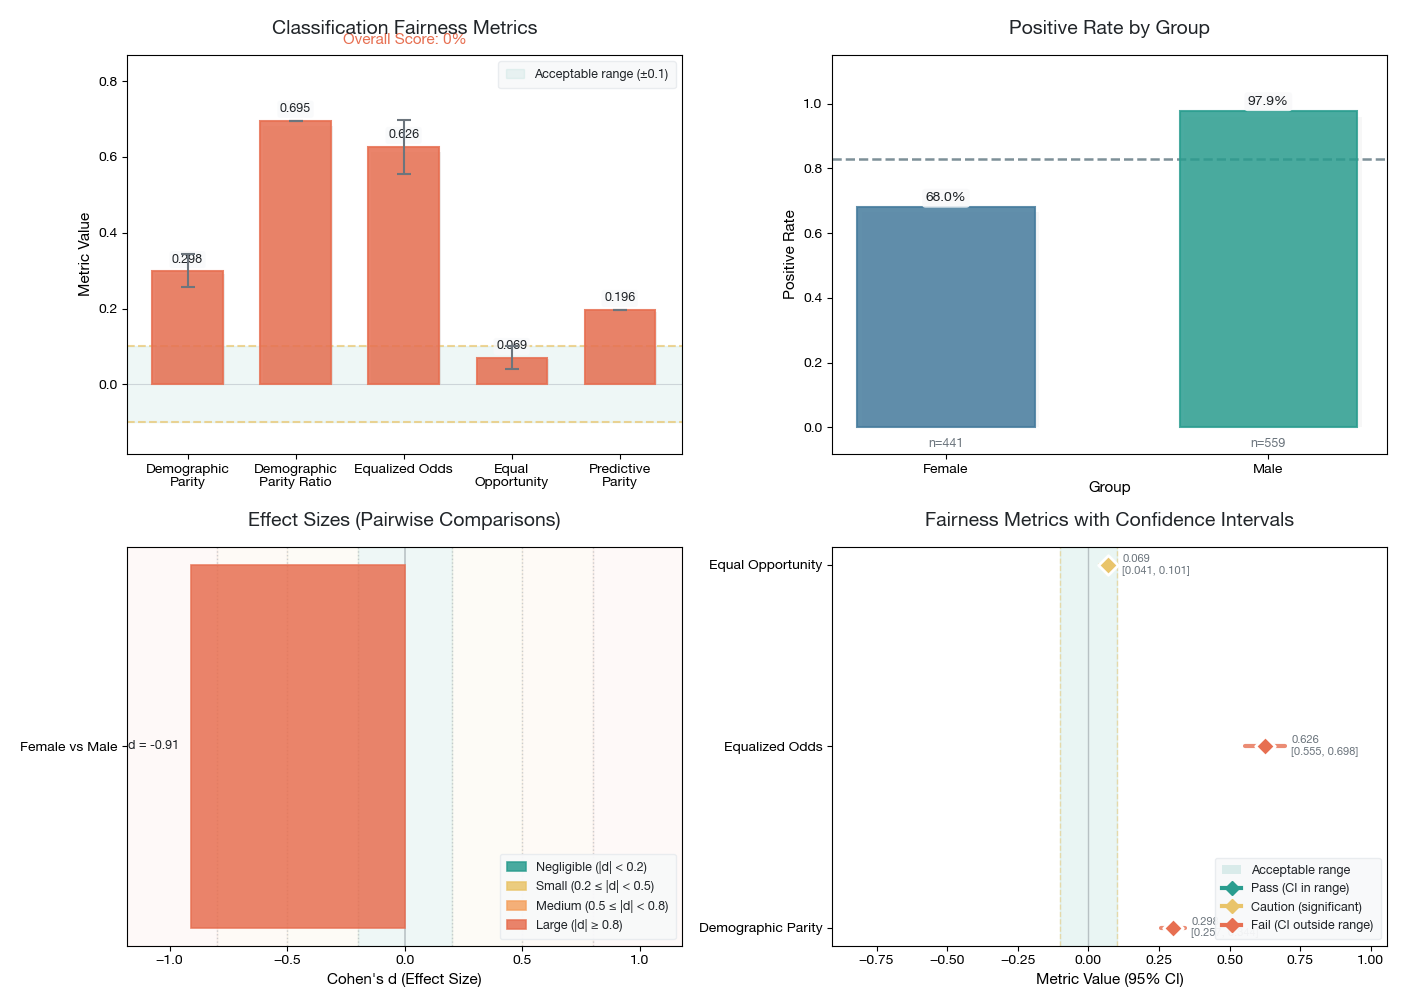

In [29]:
if VISUALIZATION_AVAILABLE:
    # Generate report with CI for visualization
    viz_report = classification_fairness_report(
        y_true, y_pred, gender,
        include_ci=True,
        n_bootstrap=1000,
        random_state=42
    )
    
    # Plot metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_fairness_metrics(viz_report, ax=axes[0, 0])
    plot_group_comparison(viz_report, metric='positive_rate', ax=axes[0, 1])
    plot_effect_sizes(viz_report, ax=axes[1, 0])
    plot_confidence_intervals(viz_report, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()

### 17a. Interactive Plotly Dashboard

The visualization module supports **Plotly** for modern, interactive dashboards with 4 professional styles: `academic`, `business`, `modern`, and `dark`. These are suitable for presentations, reports, and web embedding.

In [30]:
# Interactive Plotly Dashboard (requires: pip install plotly)
try:
    from vfairness.evaluation.vfairness_metrics.visualization import create_fairness_dashboard, get_available_styles

    print(f"Available visualization styles: {get_available_styles()}")

    # Create interactive dashboard - 'modern' style
    dashboard = create_fairness_dashboard(viz_report, style='modern', height=800)
    dashboard.show()

except ImportError as e:
    print(f"Plotly not available: {e}")
    print("Install with: pip install plotly")

Available visualization styles: ['academic', 'business', 'modern', 'dark', 'nature', 'accessible']


In [31]:
# Compare styles: 'business' style for corporate reports
try:
    dashboard_business = create_fairness_dashboard(viz_report, style='business', height=800)
    dashboard_business.show()
except Exception as e:
    print(f"Could not create business dashboard: {e}")

### 17b. Radar Chart & Heatmap (Plotly)

**Radar/Spider chart**: Compare all fairness metrics at a glance — excellent for presentations.  
**Group Disparity Heatmap**: Pairwise differences between groups in a matrix view.

In [32]:
# Radar/Spider Chart — All metrics at a glance
try:
    from vfairness.evaluation.vfairness_metrics.visualization import plot_metrics_radar

    # Normalized radar (values relative to threshold, 1.0 = at threshold)
    radar_fig = plot_metrics_radar(viz_report, style='modern', normalize=True, fill=True)
    radar_fig.show()

    # Un-normalized radar (raw metric values)
    radar_raw = plot_metrics_radar(viz_report, style='academic', normalize=False, fill=False)
    radar_raw.show()

except ImportError as e:
    print(f"Radar chart not available: {e}")
except Exception as e:
    print(f"Radar chart error: {e}")

In [33]:
# Group Disparity Heatmap — Pairwise differences between groups
try:
    from vfairness.evaluation.vfairness_metrics.visualization import plot_group_disparity_heatmap

    heatmap_fig = plot_group_disparity_heatmap(viz_report, style='modern')
    heatmap_fig.show()

except ImportError as e:
    print(f"Heatmap not available: {e}")
except Exception as e:
    print(f"Heatmap error: {e}")

### 17c. Matplotlib Style Comparison — Full Reports

Compare the **4 built-in style themes** side-by-side using the full multi-panel `plot_fairness_report` function.  
Each style generates a publication-ready 4-panel figure (metrics overview, group comparison, effect sizes, confidence intervals).

Available styles: ['academic', 'business', 'modern', 'dark', 'nature', 'accessible']

  ACADEMIC STYLE — Publication-Ready Report


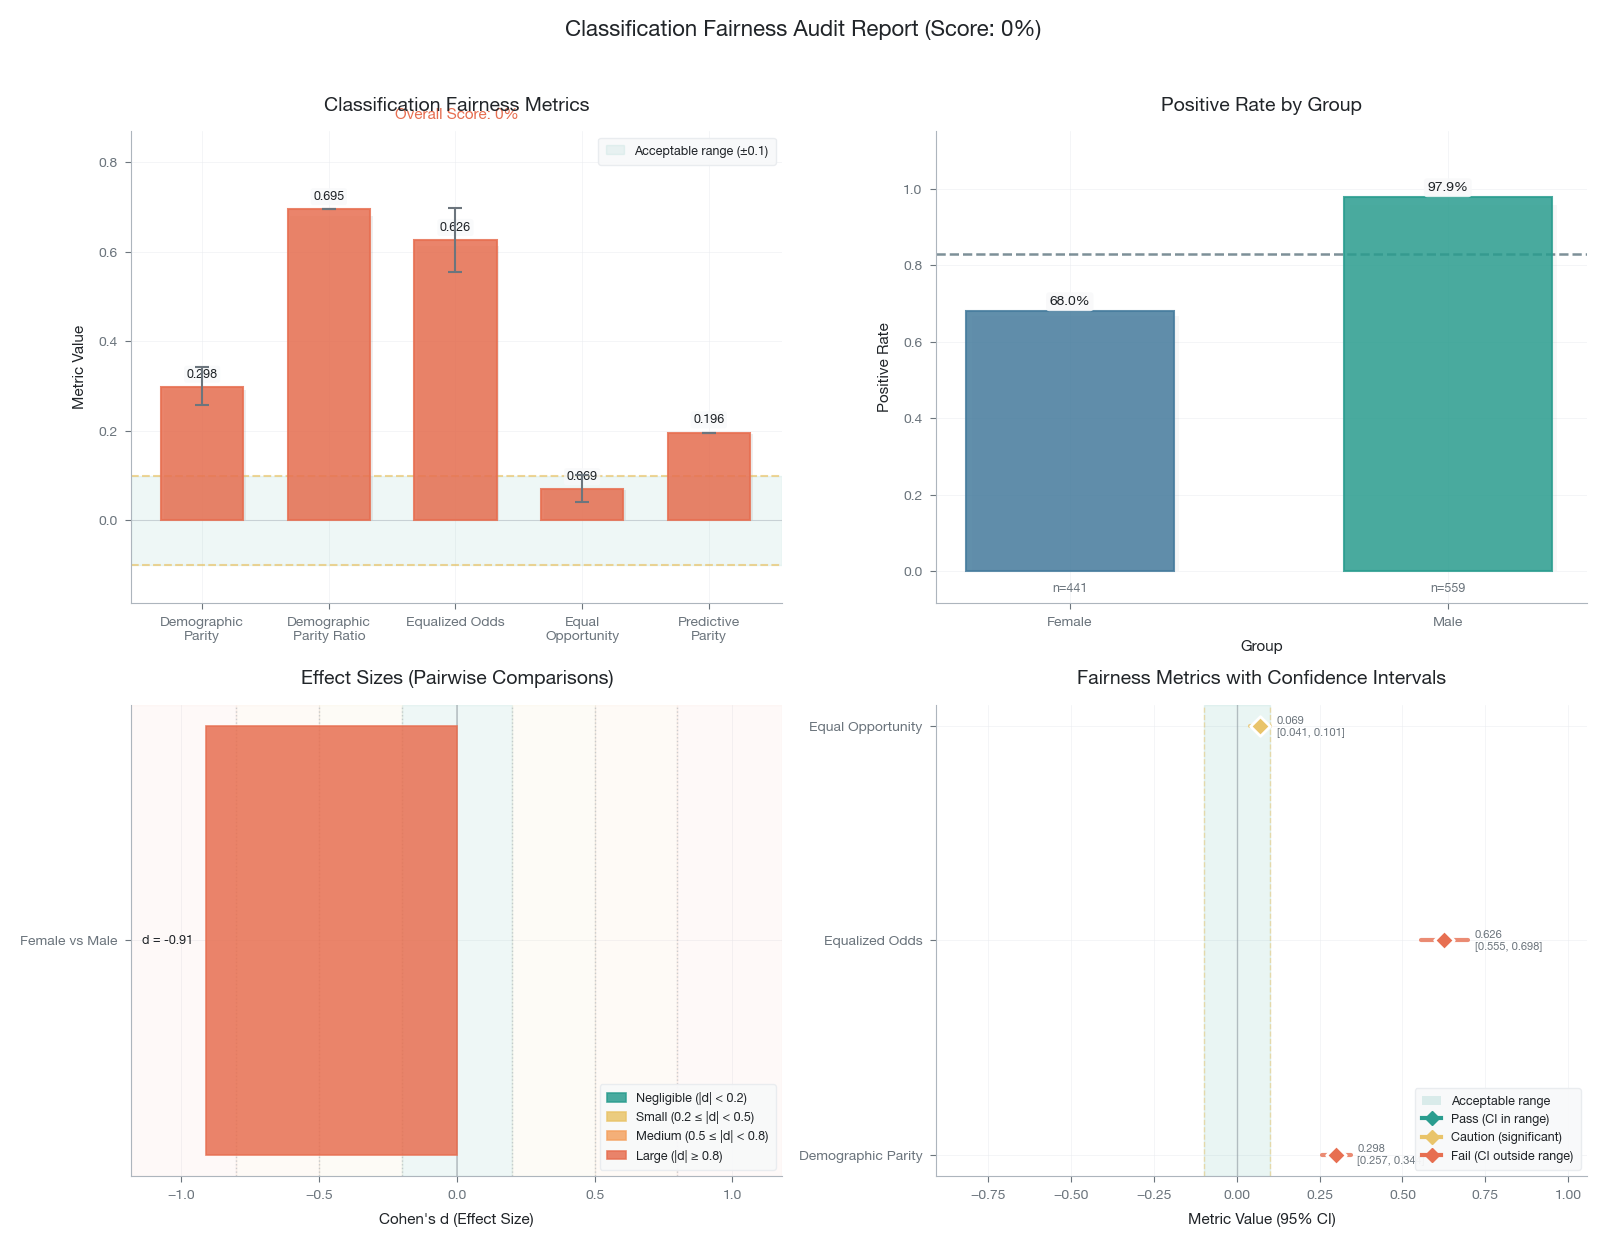

In [34]:
# Full Fairness Report — Academic Style (publication-ready, muted tones)
from vfairness.evaluation.vfairness_metrics.visualization import plot_fairness_report, get_available_styles

print(f"Available styles: {get_available_styles()}\n")

print("=" * 60)
print("  ACADEMIC STYLE — Publication-Ready Report")
print("=" * 60)
fig_academic = plot_fairness_report(viz_report, figsize=(16, 12), style='academic')
plt.show()
print()

  BUSINESS STYLE — Corporate Report


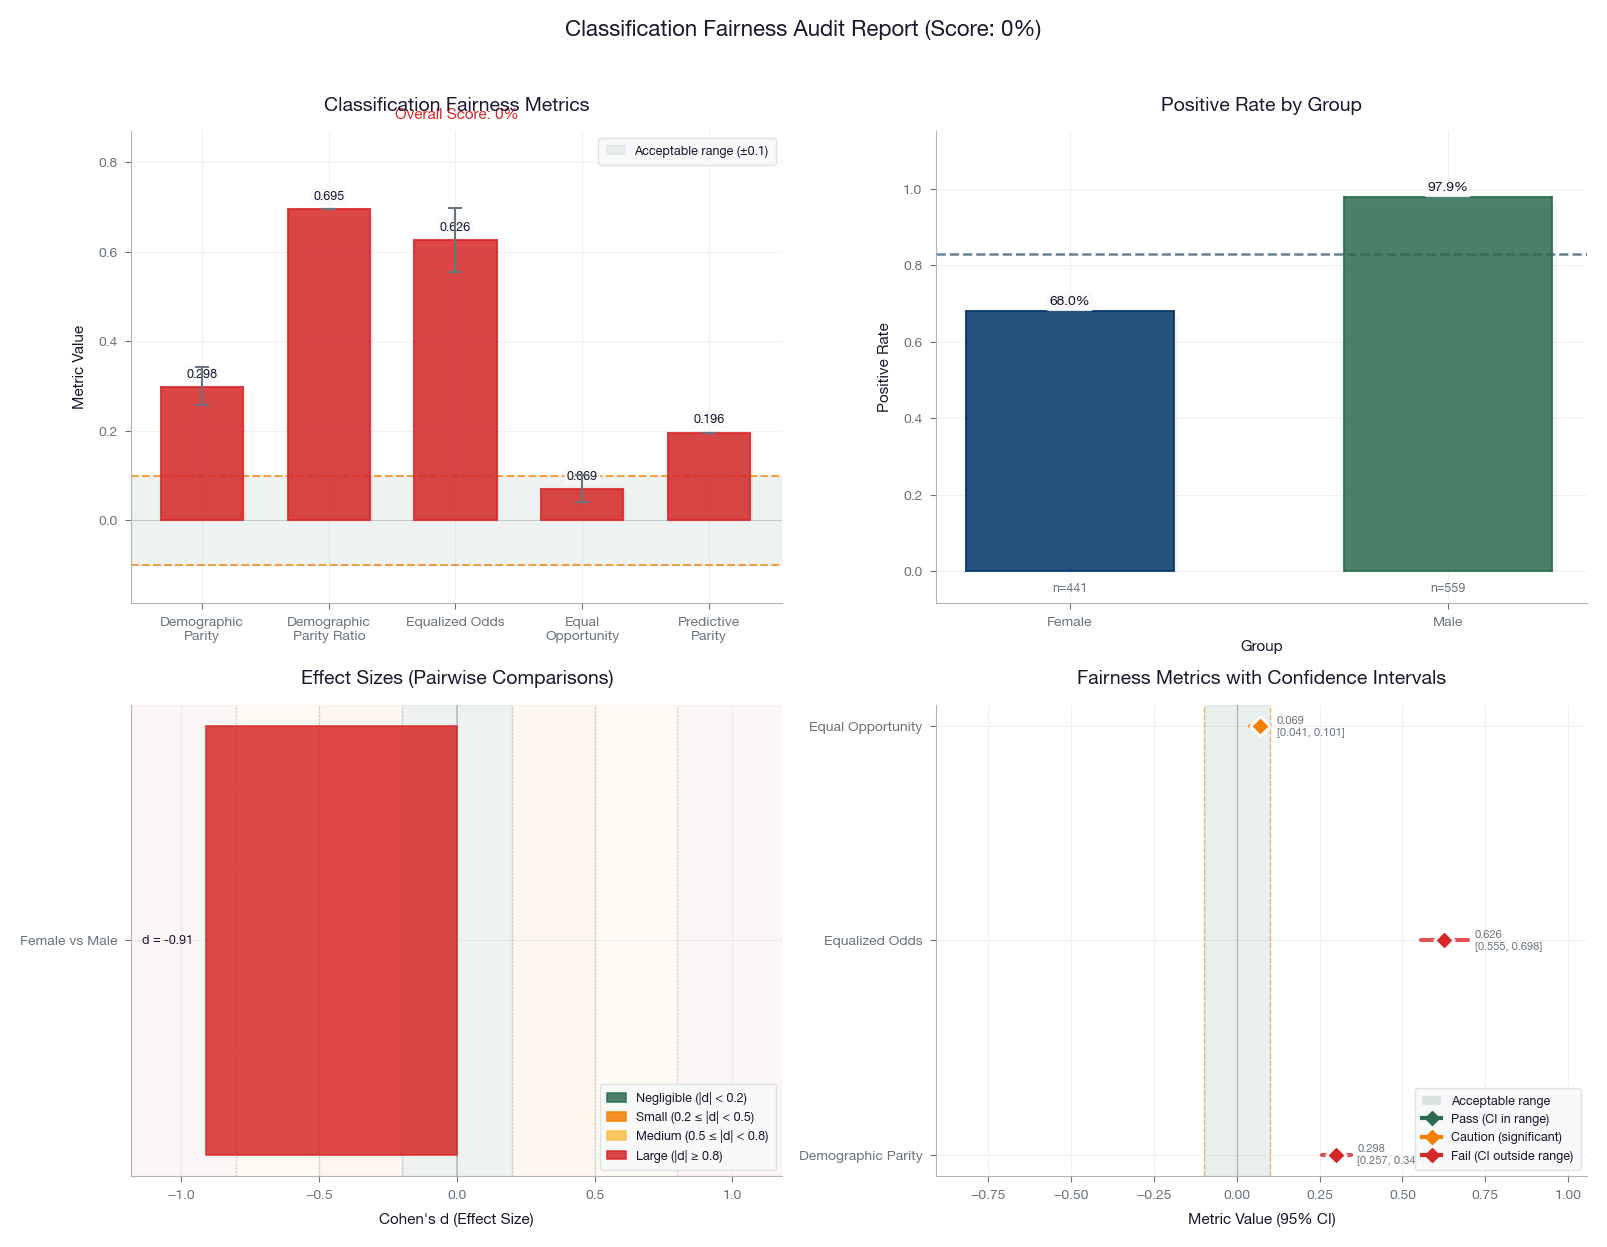

In [35]:
# Full Fairness Report — Business Style (corporate-friendly, bold colours)
print("=" * 60)
print("  BUSINESS STYLE — Corporate Report")
print("=" * 60)
fig_business = plot_fairness_report(viz_report, figsize=(16, 12), style='business')
plt.show()
print()

  MODERN STYLE — Contemporary Report


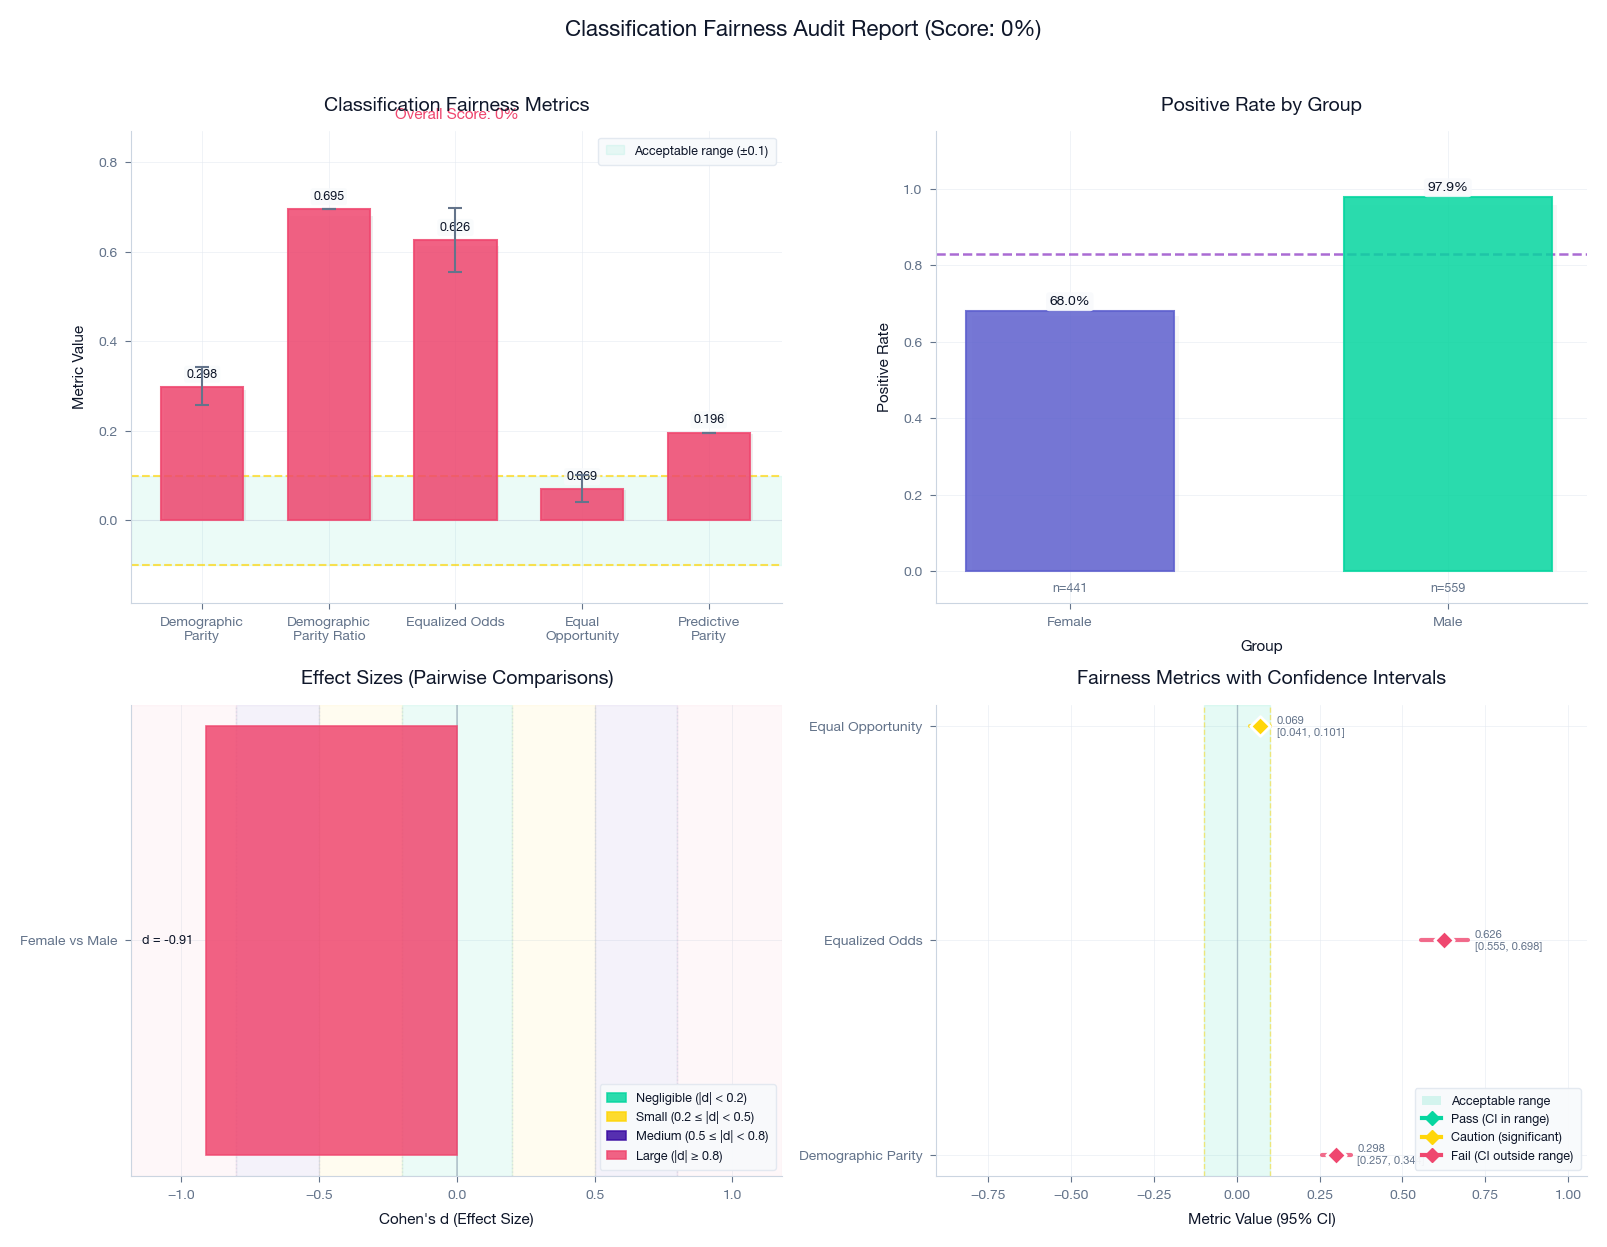

In [36]:
# Full Fairness Report — Modern Style (vibrant, gradient-inspired)
print("=" * 60)
print("  MODERN STYLE — Contemporary Report")
print("=" * 60)
fig_modern = plot_fairness_report(viz_report, figsize=(16, 12), style='modern')
plt.show()
print()

  DARK STYLE — Dark-Mode Report


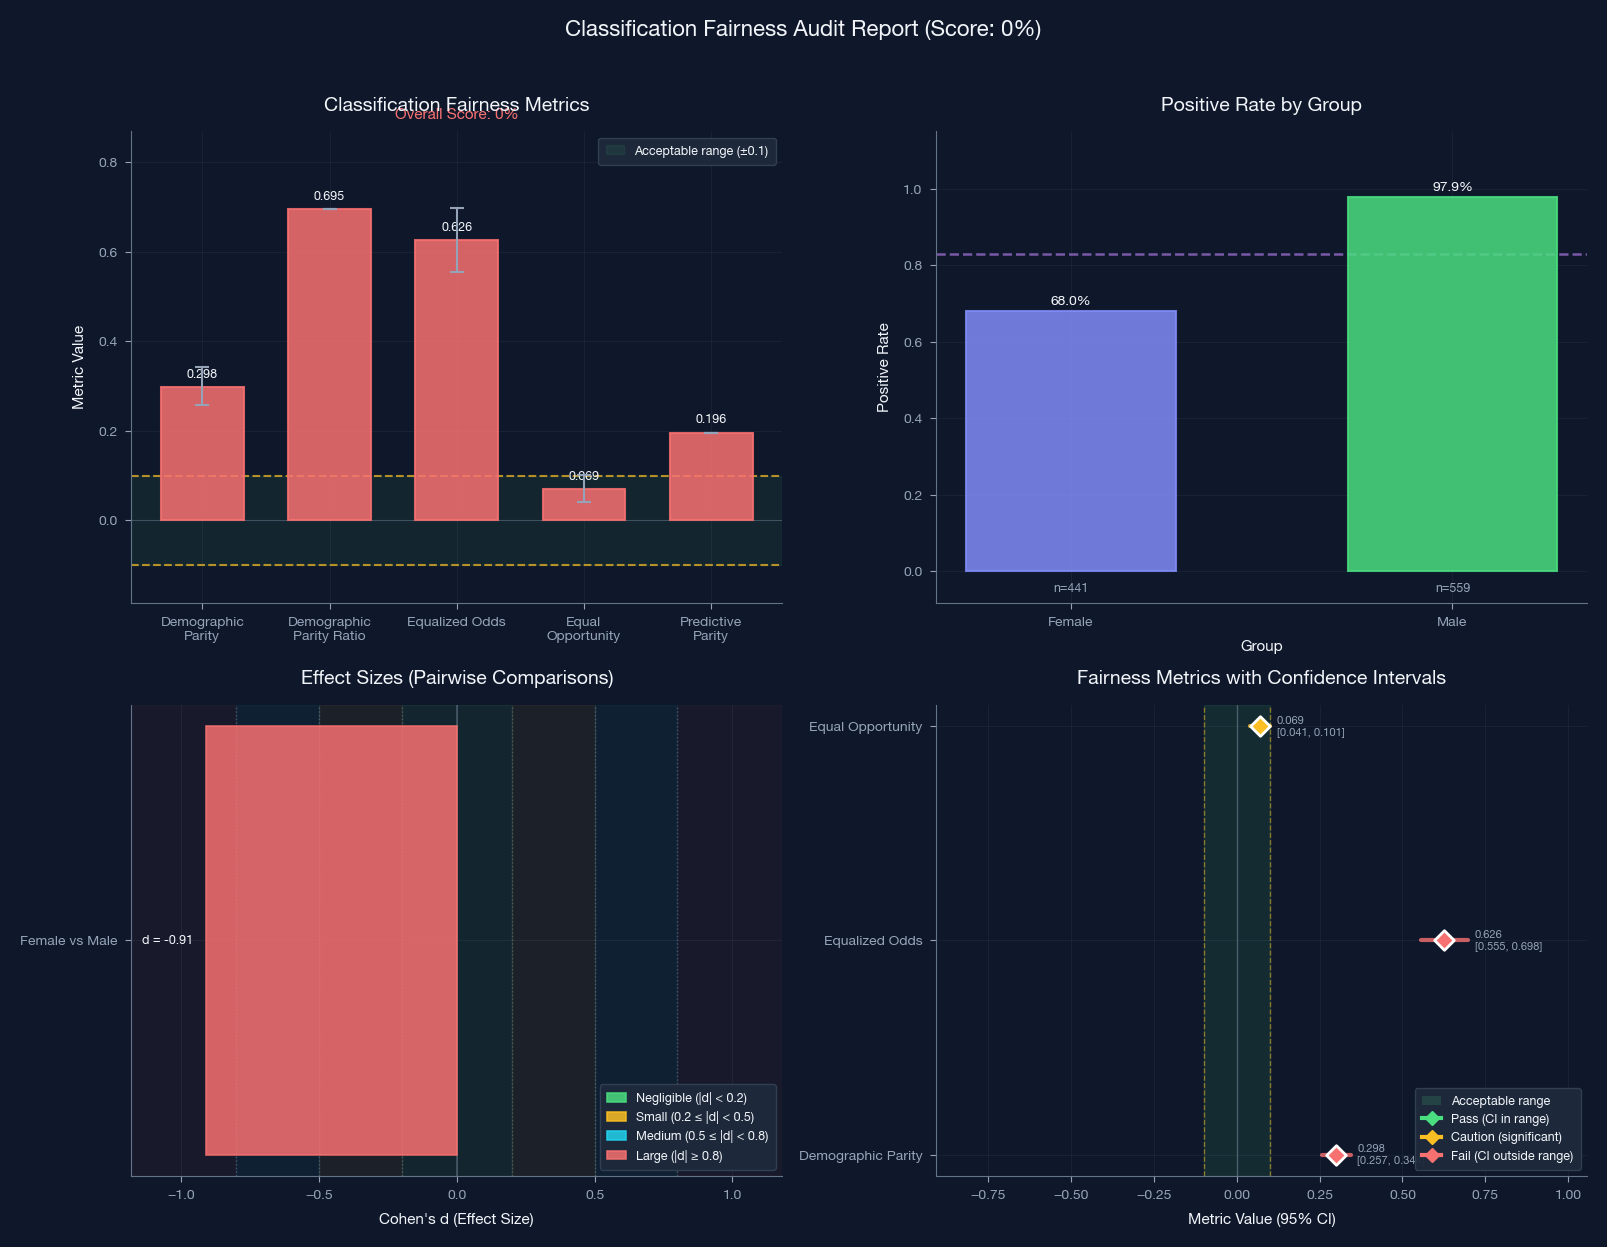

In [37]:
# Full Fairness Report — Dark Style (dark background, high contrast)
print("=" * 60)
print("  DARK STYLE — Dark-Mode Report")
print("=" * 60)
fig_dark = plot_fairness_report(viz_report, figsize=(16, 12), style='dark')
plt.show()
print()

### 17d. Colour Palette Preview & Save Plots to Files

Preview each style's colour palette and demonstrate saving all plots to disk.

In [38]:
# Preview colour palettes for all 4 styles
from vfairness.evaluation.vfairness_metrics.visualization import preview_palette, get_available_styles

styles = get_available_styles()
print(f"Previewing palettes for {len(styles)} styles: {styles}\n")

for style in styles:
    print(f"--- {style.upper()} palette ---")
    palette_fig = preview_palette(style)
    if palette_fig is not None:
        # Plotly returns a figure; matplotlib returns a Figure too
        if hasattr(palette_fig, 'show'):
            palette_fig.show()
        else:
            plt.show()
    print()

Previewing palettes for 6 styles: ['academic', 'business', 'modern', 'dark', 'nature', 'accessible']

--- ACADEMIC palette ---



--- BUSINESS palette ---



--- MODERN palette ---



--- DARK palette ---



--- NATURE palette ---



--- ACCESSIBLE palette ---


In [39]:
# How to save all fairness plots to files (one per panel + combined report)
# ─── Example usage (commented out to avoid writing files during demo) ───

from vfairness.evaluation.vfairness_metrics.visualization import save_fairness_plots

print("💾 save_fairness_plots() — Export publication-ready figures to disk\n")
print("Usage:")
print("  from vfairness.evaluation.vfairness_metrics.visualization import save_fairness_plots")
print()
print("  # Save as PNG (academic style, 300 dpi)")
print("  saved_paths = save_fairness_plots(")
print("      report,")
print("      output_dir='./fairness_plots',")
print("      prefix='demo_academic',")
print("      format='png',")
print("      style='academic',")
print("      dpi=300")
print("  )")
print()
print("  # Save as SVG for vector graphics (modern style)")
print("  saved_svg = save_fairness_plots(")
print("      report,")
print("      output_dir='./fairness_plots',")
print("      prefix='demo_modern',")
print("      format='svg',")
print("      style='modern'")
print("  )")
print()
print("Supported formats: 'png', 'svg', 'pdf', 'eps'")
print("Supported styles:  'academic', 'business', 'modern', 'dark'")
print()
print("Returns a list of saved file paths (one per panel + combined report).")

💾 save_fairness_plots() — Export publication-ready figures to disk

Usage:
  from vfairness.evaluation.vfairness_metrics.visualization import save_fairness_plots

  # Save as PNG (academic style, 300 dpi)
  saved_paths = save_fairness_plots(
      report,
      output_dir='./fairness_plots',
      prefix='demo_academic',
      format='png',
      style='academic',
      dpi=300
  )

  # Save as SVG for vector graphics (modern style)
  saved_svg = save_fairness_plots(
      report,
      output_dir='./fairness_plots',
      prefix='demo_modern',
      format='svg',
      style='modern'
  )

Supported formats: 'png', 'svg', 'pdf', 'eps'
Supported styles:  'academic', 'business', 'modern', 'dark'

Returns a list of saved file paths (one per panel + combined report).


### 📊 SVG Visualization Plot Templates

The `vfairness.rendering` module also provides SVG templates for individual visualization plots.
These render directly from the analyzer's report dict — no Plotly/Matplotlib needed.

In [ ]:
# SVG Radar Chart — fairness metrics spider plot
import sys
for key in list(sys.modules.keys()):
    if key.startswith('vfairness.rendering'):
        del sys.modules[key]

from vfairness.rendering import (
    radar_chart_to_svg, disparity_heatmap_to_svg, metrics_bar_chart_to_svg,
    group_comparison_to_svg, effect_sizes_to_svg, confidence_intervals_to_svg,
)
from IPython.display import SVG, display

svg = radar_chart_to_svg(report)
print(f'Radar Chart SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Disparity Heatmap — group × metric heatmap
svg = disparity_heatmap_to_svg(report)
print(f'Disparity Heatmap SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Metrics Bar Chart — horizontal bars with pass/fail badges
svg = metrics_bar_chart_to_svg(report)
print(f'Metrics Bar Chart SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Group Comparison — per-group metric comparison
svg = group_comparison_to_svg(report, metric='positive_rate')
print(f'Group Comparison SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Effect Sizes — Cohen's d lollipop chart
svg = effect_sizes_to_svg(report)
print(f'Effect Sizes SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Confidence Intervals — forest plot with CIs
svg = confidence_intervals_to_svg(report)
print(f'Confidence Intervals SVG: {len(svg):,} bytes')
display(SVG(data=svg))

---
## FairnessExplainer — Unified Explanation Facade

In addition to the `FairExplAIner` (which explains evaluation metrics), the library now provides a unified `FairnessExplainer` facade that can generate educational explanations for **any** result object across all modules — from bias audits to drift detection.

In [ ]:
# FairnessExplainer — works with any result type from any module
from vfairness.explainer import FairnessExplainer

# Show all registered result types
print("Registered result types:")
for t in FairnessExplainer.registered_types():
    print(f"  • {t}")
print()

# Every major class now has get_explanation():
# - BiasDetector.get_explanation()
# - CalibrationAnalyzer.get_explanation()
# - FairnessTrainingAnalyzer.get_explanation()
# - ThresholdAnalyzer.get_explanation()
# - ReweightingAnalyzer.get_explanation()
# - FeatureEngineeringAnalyzer.get_explanation()
# - FairnessDriftDetector.get_explanation(result)
# - FairnessMonitor.get_explanation()
# - DataBiasValidator.get_explanation(result)
# - ModelFairnessGate.get_explanation(decision)
print("FairnessExplainer facade ready — use FairnessExplainer.explain(any_result)")

In [ ]:
# ── Validation · FairnessExplainer ───────────────────────────────────────────────────────────
from vfairness.explainer import FairnessExplainer, ExplanationReport

# Verify all 10 types are registered
registered = FairnessExplainer.registered_types()
expected_types = [
    'BiasAuditReport', 'CalibrationReport', 'DataValidationResult',
    'FairnessTrainingReport', 'FeatureAnalysisReport', 'GateDecision',
    'MultiscaleDriftResult', 'ReweightingAnalysisReport',
    'ThresholdAnalysisReport', 'WindowMetrics',
]
for t in expected_types:
    assert t in registered, f"Missing registered type: {t}"

print(f"✓ FairnessExplainer | {len(registered)} result types registered | all expected types present")